# 3D Point Cloud Classification - Full Colab Run

This is the single notebook for the project workflow on Google Colab T4. It mounts Google Drive, clones or updates the GitHub repo, installs dependencies, copies private metadata from Drive, prepares a balanced subset, runs training experiments, compares configurations, and saves results.

Default mode is a fast synthetic point-cloud experiment derived from the label metadata. This keeps the notebook runnable before the full Cap3D `.ply` preprocessing pipeline is ready. The real Cap3D download remains optional and disabled by default.

In [71]:
REPO_URL = "https://github.com/SalmaneSossey/graphcnn-federated-3d.git"
REPO_DIR = "/content/graphcnn-federated-3d"
BRANCH = "main"

DRIVE_PROJECT_DIR = "/content/drive/MyDrive/graphcnn-federated-3d"
DRIVE_METADATA_CSV = f"{DRIVE_PROJECT_DIR}/labeled_dataset.csv"

DOWNLOAD_CAP3D_FILES = False
PREPARE_REAL_SUBSET = True
USE_REAL_POINT_CLOUDS = True
POINTCLOUD_ROOT = "data/processed/pointclouds"

FAST_DEV_RUN = True
SEED = 42
NUM_POINTS = 256 if FAST_DEV_RUN else 1024
SUBSET_CLASSES = 10
SAMPLES_PER_CLASS = 40 if FAST_DEV_RUN else 100
BATCH_SIZE = 32
CENTRALIZED_EPOCHS = 3 if FAST_DEV_RUN else 15
HFL_ROUNDS = 2 if FAST_DEV_RUN else 8
HFL_LOCAL_EPOCHS = 1 if FAST_DEV_RUN else 2
VFL_EPOCHS = 3 if FAST_DEV_RUN else 10
DISTILL_EPOCHS = 3 if FAST_DEV_RUN else 10
NUM_CLIENTS = 5

print("Repo:", REPO_URL)
print("Drive metadata:", DRIVE_METADATA_CSV)
print("Fast dev run:", FAST_DEV_RUN)
print("Use real point clouds:", USE_REAL_POINT_CLOUDS)
print("Num points:", NUM_POINTS)


Repo: https://github.com/SalmaneSossey/graphcnn-federated-3d.git
Drive metadata: /content/drive/MyDrive/graphcnn-federated-3d/labeled_dataset.csv
Fast dev run: True
Use real point clouds: True
Num points: 256


In [88]:
!ls -lh data/raw/PointCloud_zips_ShapeNet/

total 26G
-rw-r--r-- 1 root root 2.2M May 31 18:20 compressed_files_info.pkl
-rw-r--r-- 1 root root  26G May 31 18:20 compressed_pcs_00.zip


## 1. Mount Google Drive

Keep private data in Drive. GitHub stays code-only.

Expected private metadata path:

`MyDrive/graphcnn-federated-3d/labeled_dataset.csv`

In [72]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Clone or Update the Repository

In [73]:
from pathlib import Path
import os
import shutil
import subprocess


def run(command, check=True):
    print("$", " ".join(str(part) for part in command))
    return subprocess.run(command, check=check)

repo_path = Path(REPO_DIR)
if repo_path.exists():
    os.chdir(REPO_DIR)
    run(["git", "fetch", "origin"])
    run(["git", "checkout", BRANCH])
    run(["git", "pull", "--ff-only", "origin", BRANCH])
else:
    run(["git", "clone", "--branch", BRANCH, REPO_URL, REPO_DIR])
    os.chdir(REPO_DIR)

print("Working directory:", os.getcwd())

$ git fetch origin
$ git checkout main
$ git pull --ff-only origin main
Working directory: /content/graphcnn-federated-3d


## 3. Install Dependencies

Colab already includes CUDA-enabled PyTorch, so `requirements-colab.txt` does not reinstall `torch`.

In [74]:
!python -m pip install --upgrade pip
!python -m pip install -r requirements-colab.txt

## 4. Imports, Device, and Reproducibility

In [75]:
import copy
import math
import time
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset, Subset

from src.data.dataset import ShapeNetPointCloudDataset
from src.distillation.losses import distillation_loss
from src.federated.fedavg import aggregate_state_dicts
from src.federated.vfl import VFLEntityEncoder, VFLServerClassifier, split_xyz_rgb
from src.models.common import PointCloudMLP, count_parameters
from src.models.pointgcn import PointGCN
from src.models.rscnn import RSCNN
from src.models.student import StudentPointCloudMLP
from src.training.metrics import accuracy, mean_per_class_accuracy
from src.utils.seed import seed_everything

seed_everything(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Path("data/metadata").mkdir(parents=True, exist_ok=True)
Path("data/raw").mkdir(parents=True, exist_ok=True)
Path("data/processed").mkdir(parents=True, exist_ok=True)
Path("data/splits").mkdir(parents=True, exist_ok=True)
Path("outputs").mkdir(parents=True, exist_ok=True)
Path("checkpoints").mkdir(parents=True, exist_ok=True)
Path("reports/figures").mkdir(parents=True, exist_ok=True)

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")
!nvidia-smi || true

Torch: 2.11.0+cu128
CUDA available: True
Device: Tesla T4
Sun May 31 18:28:17 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   62C    P0             27W /   70W |     185MiB /  15360MiB |      0%      Default |
|                                         |                        |              

## 5. Copy Metadata from Drive

The CSV is copied into `data/metadata/labeled_dataset.csv` inside Colab. That path is ignored by Git.

In [76]:
drive_project = Path(DRIVE_PROJECT_DIR)
drive_project.mkdir(parents=True, exist_ok=True)
repo_metadata = Path("data/metadata/labeled_dataset.csv")
drive_metadata = Path(DRIVE_METADATA_CSV)

if drive_metadata.exists():
    shutil.copy2(drive_metadata, repo_metadata)
    print(f"Copied {drive_metadata} -> {repo_metadata}")
elif repo_metadata.exists():
    print(f"Using existing local metadata at {repo_metadata}")
else:
    print(f"Metadata not found at {drive_metadata}")
    print("The notebook will create a synthetic fallback label table so the full workflow still runs.")

Copied /content/drive/MyDrive/graphcnn-federated-3d/labeled_dataset.csv -> data/metadata/labeled_dataset.csv


## 6. Optional Cap3D Download and Real Subset Preparation

Both switches are off by default. Turn on `DOWNLOAD_CAP3D_FILES` only when you intentionally want to fetch selected Cap3D files. Turn on `PREPARE_REAL_SUBSET` after the ZIP exists in `data/raw`; the script extracts only selected `.ply` files, not the whole archive.


In [89]:
if DOWNLOAD_CAP3D_FILES:
    !python scripts/download_cap3d.py --data-dir data/raw
else:
    print("Skipped Cap3D download. Set DOWNLOAD_CAP3D_FILES=True in the first cell when needed.")

if PREPARE_REAL_SUBSET:
    !python scripts/prepare_subset.py --subset-classes {SUBSET_CLASSES} --samples-per-class {SAMPLES_PER_CLASS}
else:
    print("Skipped real subset extraction. Set PREPARE_REAL_SUBSET=True after a Cap3D ZIP is available in data/raw.")


Skipped Cap3D download. Set DOWNLOAD_CAP3D_FILES=True in the first cell when needed.
Found 1 ZIP file(s) under data/raw.
Extracting PLY subset: 100% 400/400 [01:22<00:00,  4.87it/s]
train: 280 rows
val: 60 rows
test: 60 rows
Extracted 400/400 selected point clouds.
Point-cloud root: data/processed/pointclouds
Split CSVs: data/splits


## 7. Metadata Inspection and Balanced Subset

The training demo uses labels from `labeled_dataset.csv` when available. If the CSV is missing, it creates a small fallback label table so every project component can still run.

In [91]:
if repo_metadata.exists():
    metadata = pd.read_csv(repo_metadata)
    print("Metadata rows:", len(metadata))
    print("Columns:", list(metadata.columns))
    display(metadata.head())
else:
    fallback_labels = [f"class_{i}" for i in range(SUBSET_CLASSES)]
    metadata = pd.DataFrame(
        {
            "id": [f"synthetic_{label}_{idx}" for label in fallback_labels for idx in range(SAMPLES_PER_CLASS)],
            "description": ["synthetic fallback point cloud"] * (len(fallback_labels) * SAMPLES_PER_CLASS),
            "label": [label for label in fallback_labels for _ in range(SAMPLES_PER_CLASS)],
        }
    )
    print("Using synthetic fallback metadata.")
    display(metadata.head())

label_candidates = [c for c in metadata.columns if "label" in c.lower() or "class" in c.lower() or "category" in c.lower()]
label_col = "label" if "label" in metadata.columns else (label_candidates[0] if label_candidates else None)
if label_col is None:
    raise ValueError("Could not infer a label column. Add a `label` column to labeled_dataset.csv.")

label_counts = metadata[label_col].astype(str).value_counts()
chosen_labels = label_counts.head(SUBSET_CLASSES).index.tolist()
subset_df = (
    metadata[metadata[label_col].astype(str).isin(chosen_labels)]
    .assign(label_name=lambda frame: frame[label_col].astype(str))
    .groupby("label_name", group_keys=False)
    .head(SAMPLES_PER_CLASS)
    .sample(frac=1.0, random_state=SEED)
    .reset_index(drop=True)
)
label_to_idx = {label: idx for idx, label in enumerate(sorted(subset_df["label_name"].unique()))}
subset_df["label_idx"] = subset_df["label_name"].map(label_to_idx).astype(int)
num_classes = len(label_to_idx)

print("Chosen labels:", chosen_labels)
print("Subset rows:", len(subset_df))
print("Num classes:", num_classes)
display(subset_df["label_name"].value_counts().rename_axis("label").reset_index(name="count"))
subset_df.to_csv("data/splits/selected_subset.csv", index=False)

Metadata rows: 50074
Columns: ['id', 'description', 'label']


,id,description,label
0,03001627_5ceabffee1c333293002761e7a3ba3bd,A modern office chair featuring a plush green ...,chair
1,04090263_4ce26b6d23caecb3cc34b900bb2492e,A modern tactical rifle featuring an ergonomic...,rifle
2,03001627_7178731312819be3ecb14096838a20c5,A modern chair featuring a sleek design with a...,chair
3,03691459_91b781b40d32b74dc491effd0ae881ea,A rectangular storage unit featuring a promine...,loudspeaker
4,04401088_c3b9cb70c6a80ed686a04ec9e4169973,"A sleek, rectangular smartphone featuring a gl...",telephone


Chosen labels: ['table', 'chair', 'airplane', 'car', 'sofa', 'rifle', 'lamp', 'watercraft', 'bench', 'loudspeaker']
Subset rows: 400
Num classes: 10


,label,count
0,sofa,40
1,lamp,40
2,rifle,40
3,car,40
4,bench,40
5,watercraft,40
6,chair,40
7,airplane,40
8,table,40
9,loudspeaker,40


## 8. Deterministic Train/Validation/Test Splits

In [92]:
def stratified_split(frame, label_column="label_idx", train_frac=0.70, val_frac=0.15, seed=42):
    rng = np.random.default_rng(seed)
    train_parts, val_parts, test_parts = [], [], []
    for _, group in frame.groupby(label_column):
        indices = group.index.to_numpy()
        rng.shuffle(indices)
        n = len(indices)
        n_train = max(1, int(round(n * train_frac)))
        n_val = max(1, int(round(n * val_frac))) if n - n_train > 1 else 0
        train_parts.append(frame.loc[indices[:n_train]])
        val_parts.append(frame.loc[indices[n_train:n_train + n_val]])
        test_parts.append(frame.loc[indices[n_train + n_val:]])
    splits = {
        "train": pd.concat(train_parts).sample(frac=1.0, random_state=seed).reset_index(drop=True),
        "val": pd.concat(val_parts).sample(frac=1.0, random_state=seed).reset_index(drop=True),
        "test": pd.concat(test_parts).sample(frac=1.0, random_state=seed).reset_index(drop=True),
    }
    return splits

splits = stratified_split(subset_df, seed=SEED)
for name, split_df in splits.items():
    split_df.to_csv(f"data/splits/{name}.csv", index=False)
    print(name, split_df.shape)

train (280, 5)
val (60, 5)
test (60, 5)


## 9. Dataset Selection

If `USE_REAL_POINT_CLOUDS=True` and `data/splits/train.csv`, `val.csv`, and `test.csv` exist from `scripts/prepare_subset.py`, the notebook trains on extracted real `.ply` files. Otherwise it uses a deterministic synthetic point-cloud proxy derived from your labels so every training section remains runnable.


In [93]:
class SyntheticPointCloudDataset(Dataset):
    def __init__(self, frame, num_points=256, input_channels=6, seed=42):
        self.frame = frame.reset_index(drop=True)
        self.num_points = num_points
        self.input_channels = input_channels
        self.seed = seed
        self.class_ids = sorted(self.frame["label_idx"].unique())
        rng = np.random.default_rng(seed)
        self.centers = {
            class_id: rng.normal(loc=0.0, scale=1.5, size=(1, 6)).astype(np.float32)
            for class_id in self.class_ids
        }

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, index):
        row = self.frame.iloc[index]
        label = int(row["label_idx"])
        stable_id = str(row.get("id", index))
        item_seed = (abs(hash((stable_id, label, self.seed))) % (2**32 - 1))
        rng = np.random.default_rng(item_seed)
        center = self.centers[label]
        points = center + rng.normal(0.0, 0.35, size=(self.num_points, 6)).astype(np.float32)
        points[:, :3] -= points[:, :3].mean(axis=0, keepdims=True)
        scale = np.linalg.norm(points[:, :3], axis=1).max()
        if scale > 0:
            points[:, :3] /= scale
        points[:, 3:] = np.clip(points[:, 3:], 0.0, 1.0)
        if self.input_channels == 3:
            points = points[:, :3]
        return torch.from_numpy(points).float(), torch.tensor(label, dtype=torch.long)


def real_split_csvs_are_ready(split_paths, pointcloud_root):
    if not all(path.exists() for path in split_paths.values()):
        return False, "train/val/test split CSVs are missing"
    try:
        split_frames = {name: pd.read_csv(path) for name, path in split_paths.items()}
    except Exception as exc:
        return False, f"could not read split CSVs: {exc}"
    required_columns = {"file_path", "label_idx"}
    for name, frame in split_frames.items():
        missing = required_columns.difference(frame.columns)
        if missing:
            return False, f"{name}.csv is missing columns: {sorted(missing)}"
        if frame.empty:
            return False, f"{name}.csv is empty"
    combined = pd.concat(split_frames.values(), ignore_index=True)
    sample_paths = combined["file_path"].head(25).astype(str)
    existing = []
    for relative_path in sample_paths:
        candidate = Path(relative_path)
        if not candidate.is_absolute():
            candidate = Path(pointcloud_root) / candidate
        existing.append(candidate.exists())
    if not any(existing):
        return False, f"no referenced .ply files found under {pointcloud_root}"
    return True, split_frames

split_paths = {name: Path(f"data/splits/{name}.csv") for name in ["train", "val", "test"]}
real_ready, real_info = real_split_csvs_are_ready(split_paths, POINTCLOUD_ROOT)

if USE_REAL_POINT_CLOUDS and real_ready:
    print("Using real extracted PLY datasets.")
    splits = real_info
    num_classes = int(pd.concat(splits.values())["label_idx"].nunique())
    train_dataset = ShapeNetPointCloudDataset(split_paths["train"], POINTCLOUD_ROOT, NUM_POINTS, label_column="label_idx")
    val_dataset = ShapeNetPointCloudDataset(split_paths["val"], POINTCLOUD_ROOT, NUM_POINTS, label_column="label_idx")
    test_dataset = ShapeNetPointCloudDataset(split_paths["test"], POINTCLOUD_ROOT, NUM_POINTS, label_column="label_idx")
else:
    if USE_REAL_POINT_CLOUDS:
        print(f"Requested real point clouds, but they are not ready: {real_info}")
        print("Falling back to synthetic proxy. Run prepare_subset successfully, then rerun with USE_REAL_POINT_CLOUDS=True.")
    else:
        print("Using synthetic point-cloud proxy.")
    train_dataset = SyntheticPointCloudDataset(splits["train"], num_points=NUM_POINTS, seed=SEED)
    val_dataset = SyntheticPointCloudDataset(splits["val"], num_points=NUM_POINTS, seed=SEED)
    test_dataset = SyntheticPointCloudDataset(splits["test"], num_points=NUM_POINTS, seed=SEED)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=torch.cuda.is_available())
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=torch.cuda.is_available())
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=torch.cuda.is_available())

points, targets = next(iter(train_loader))
print("Batch points:", points.shape)
print("Batch labels:", targets.shape)
print("Num classes:", num_classes)


Requested real point clouds, but they are not ready: train.csv is missing columns: ['file_path']
Falling back to synthetic proxy. Run prepare_subset successfully, then rerun with USE_REAL_POINT_CLOUDS=True.
Batch points: torch.Size([32, 256, 6])
Batch labels: torch.Size([32])
Num classes: 10


## 10. Shared Training Helpers

In [94]:
criterion = nn.CrossEntropyLoss()
experiment_rows = []


def evaluate(model, loader):
    model.eval()
    total_loss = 0.0
    logits_all, targets_all = [], []
    with torch.no_grad():
        for points, targets in loader:
            points = points.to(device)
            targets = targets.to(device)
            logits = model(points)
            loss = criterion(logits, targets)
            total_loss += loss.item() * targets.size(0)
            logits_all.append(logits.cpu())
            targets_all.append(targets.cpu())
    logits = torch.cat(logits_all)
    targets = torch.cat(targets_all)
    return {
        "loss": total_loss / max(len(targets), 1),
        "accuracy": accuracy(logits, targets),
        "mpca": mean_per_class_accuracy(logits, targets, num_classes=num_classes),
    }


def train_model(model, train_loader, val_loader, epochs, lr=1e-3, weight_decay=1e-4):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    history = []
    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0
        total_examples = 0
        for points, targets in train_loader:
            points = points.to(device)
            targets = targets.to(device)
            optimizer.zero_grad(set_to_none=True)
            logits = model(points)
            loss = criterion(logits, targets)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * targets.size(0)
            total_examples += targets.size(0)
        val_metrics = evaluate(model, val_loader)
        history.append({"epoch": epoch, "train_loss": total_loss / max(total_examples, 1), **val_metrics})
        print(f"epoch={epoch:02d} train_loss={history[-1]['train_loss']:.4f} val_acc={val_metrics['accuracy']:.4f}")
    return model, pd.DataFrame(history)


def record_result(config_name, model_name, metrics, params=None, notes=""):
    row = {
        "configuration": config_name,
        "model": model_name,
        "test_loss": metrics["loss"],
        "test_accuracy": metrics["accuracy"],
        "test_mpca": metrics["mpca"],
        "parameters": params,
        "notes": notes,
    }
    experiment_rows.append(row)
    return row

## 11. C1 - Centralized Baselines: PointGCN and RS-CNN

In [95]:
centralized_models = {
    "PointGCN": PointGCN(num_classes=num_classes, input_channels=6, hidden_dim=64),
    "RS-CNN": RSCNN(num_classes=num_classes, input_channels=6, hidden_dim=64),
}
trained_centralized = {}

for model_name, model in centralized_models.items():
    print("=== Centralized", model_name, "===")
    print("Parameters:", count_parameters(model))
    trained_model, history = train_model(model, train_loader, val_loader, epochs=CENTRALIZED_EPOCHS)
    test_metrics = evaluate(trained_model, test_loader)
    display(pd.DataFrame([test_metrics]))
    history.to_csv(f"outputs/history_centralized_{model_name.lower().replace('-', '').replace(' ', '_')}.csv", index=False)
    torch.save(trained_model.state_dict(), f"checkpoints/{model_name.lower().replace('-', '').replace(' ', '_')}_centralized.pt")
    record_result("C1 Centralized", model_name, test_metrics, count_parameters(trained_model))
    trained_centralized[model_name] = trained_model

teacher_model = trained_centralized["PointGCN"]

=== Centralized PointGCN ===
Parameters: 9418
epoch=01 train_loss=2.2909 val_acc=0.1833
epoch=02 train_loss=2.2516 val_acc=0.3000
epoch=03 train_loss=2.2027 val_acc=0.3167


,loss,accuracy,mpca
0,2.166196,0.333333,0.333333


=== Centralized RS-CNN ===
Parameters: 9418
epoch=01 train_loss=2.2970 val_acc=0.1000
epoch=02 train_loss=2.2664 val_acc=0.2000
epoch=03 train_loss=2.2250 val_acc=0.3500


,loss,accuracy,mpca
0,2.19342,0.383333,0.383333


## 12. C2/C3 - Manual Horizontal Federated Learning

Manual PyTorch flow: the server sends `copy.deepcopy(global_model)` to clients; clients train locally and return state dicts plus dataset sizes; FedAvg aggregates key by key.

In [96]:
def make_iid_client_loaders(dataset, num_clients, batch_size, seed=42):
    rng = np.random.default_rng(seed)
    indices = np.arange(len(dataset))
    rng.shuffle(indices)
    client_indices = np.array_split(indices, num_clients)
    return [DataLoader(Subset(dataset, idx.tolist()), batch_size=batch_size, shuffle=True) for idx in client_indices]


def make_non_iid_client_loaders(frame, num_clients, batch_size, seed=42):
    sorted_frame = frame.sort_values(["label_idx"]).reset_index(drop=True)
    shards = np.array_split(np.arange(len(sorted_frame)), num_clients)
    loaders = []
    for shard in shards:
        client_frame = sorted_frame.iloc[shard].reset_index(drop=True)
        client_dataset = SyntheticPointCloudDataset(client_frame, num_points=NUM_POINTS, seed=seed)
        loaders.append(DataLoader(client_dataset, batch_size=batch_size, shuffle=True))
    return loaders


def train_local_client(global_model, client_loader, local_epochs=1, lr=1e-3):
    local_model = copy.deepcopy(global_model).to(device)
    optimizer = torch.optim.Adam(local_model.parameters(), lr=lr)
    for _ in range(local_epochs):
        local_model.train()
        for points, targets in client_loader:
            points = points.to(device)
            targets = targets.to(device)
            optimizer.zero_grad(set_to_none=True)
            logits = local_model(points)
            loss = criterion(logits, targets)
            loss.backward()
            optimizer.step()
    state = {key: value.detach().cpu() for key, value in local_model.state_dict().items()}
    return state, len(client_loader.dataset)


def run_hfl_experiment(name, client_loaders):
    global_model = PointGCN(num_classes=num_classes, input_channels=6, hidden_dim=64).to(device)
    round_rows = []
    for round_idx in range(1, HFL_ROUNDS + 1):
        client_states, client_sizes = [], []
        for client_id, client_loader in enumerate(client_loaders):
            state, size = train_local_client(global_model, client_loader, local_epochs=HFL_LOCAL_EPOCHS)
            client_states.append(state)
            client_sizes.append(size)
        aggregated = aggregate_state_dicts(client_states, client_sizes)
        global_model.load_state_dict(aggregated)
        val_metrics = evaluate(global_model, val_loader)
        round_row = {"round": round_idx, "client_sizes": client_sizes, **val_metrics}
        round_rows.append(round_row)
        print(f"{name} round={round_idx:02d} val_acc={val_metrics['accuracy']:.4f} sizes={client_sizes}")
    test_metrics = evaluate(global_model, test_loader)
    pd.DataFrame(round_rows).to_csv(f"outputs/history_{name.lower().replace(' ', '_')}.csv", index=False)
    record_result(name, "PointGCN FedAvg", test_metrics, count_parameters(global_model), notes=f"{NUM_CLIENTS} clients")
    return global_model, pd.DataFrame(round_rows)

iid_loaders = make_iid_client_loaders(train_dataset, NUM_CLIENTS, BATCH_SIZE, seed=SEED)
non_iid_loaders = make_non_iid_client_loaders(splits["train"], NUM_CLIENTS, BATCH_SIZE, seed=SEED)

hfl_iid_model, hfl_iid_history = run_hfl_experiment("C2 HFL IID", iid_loaders)
hfl_non_iid_model, hfl_non_iid_history = run_hfl_experiment("C3 HFL non-IID", non_iid_loaders)

C2 HFL IID round=01 val_acc=0.1000 sizes=[56, 56, 56, 56, 56]
C2 HFL IID round=02 val_acc=0.1000 sizes=[56, 56, 56, 56, 56]
C3 HFL non-IID round=01 val_acc=0.0833 sizes=[56, 56, 56, 56, 56]
C3 HFL non-IID round=02 val_acc=0.1333 sizes=[56, 56, 56, 56, 56]


## 13. Vertical Federated Learning Simulation

Entity A owns XYZ. Entity B owns RGB. Each entity sends only embeddings to the server; raw XYZ/RGB are not exchanged.

In [97]:
class VFLSystem(nn.Module):
    def __init__(self, embedding_dim=64, num_classes=10):
        super().__init__()
        self.entity_a = VFLEntityEncoder(input_channels=3, embedding_dim=embedding_dim)
        self.entity_b = VFLEntityEncoder(input_channels=3, embedding_dim=embedding_dim)
        self.server = VFLServerClassifier(embedding_dim=embedding_dim, num_classes=num_classes)

    def forward(self, points):
        xyz, rgb = split_xyz_rgb(points)
        embedding_a = self.entity_a(xyz)
        embedding_b = self.entity_b(rgb)
        return self.server(embedding_a, embedding_b)

vfl_model = VFLSystem(embedding_dim=64, num_classes=num_classes).to(device)
print("VFL parameters:", count_parameters(vfl_model))
vfl_model, vfl_history = train_model(vfl_model, train_loader, val_loader, epochs=VFL_EPOCHS)
vfl_metrics = evaluate(vfl_model, test_loader)
record_result("VFL", "XYZ/RGB Embedding Split", vfl_metrics, count_parameters(vfl_model), notes="Entity A=XYZ, Entity B=RGB")
display(pd.DataFrame([vfl_metrics]))
vfl_history.to_csv("outputs/history_vfl.csv", index=False)

VFL parameters: 17738
epoch=01 train_loss=2.2996 val_acc=0.3000
epoch=02 train_loss=2.2720 val_acc=0.3833
epoch=03 train_loss=2.2367 val_acc=0.2833


,loss,accuracy,mpca
0,2.209961,0.316667,0.316667


## 14. C4 - Knowledge Distillation

The centralized PointGCN is the teacher. The student has at least 4x fewer parameters. The loss combines CE and KL divergence using `alpha` and temperature `tau`.

In [98]:
def train_student_with_distillation(teacher, alpha, temperature):
    teacher = teacher.to(device).eval()
    student = StudentPointCloudMLP(num_classes=num_classes, input_channels=6, hidden_dim=16).to(device)
    teacher_params = count_parameters(teacher)
    student_params = count_parameters(student)
    print(f"Teacher params={teacher_params:,} Student params={student_params:,} Ratio={teacher_params / max(student_params, 1):.2f}x")
    optimizer = torch.optim.Adam(student.parameters(), lr=1e-3)
    history = []
    for epoch in range(1, DISTILL_EPOCHS + 1):
        student.train()
        total_loss = 0.0
        total_examples = 0
        for points, targets in train_loader:
            points = points.to(device)
            targets = targets.to(device)
            optimizer.zero_grad(set_to_none=True)
            student_logits = student(points)
            with torch.no_grad():
                teacher_logits = teacher(points)
            loss = distillation_loss(student_logits, teacher_logits, targets, alpha=alpha, temperature=temperature)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * targets.size(0)
            total_examples += targets.size(0)
        val_metrics = evaluate(student, val_loader)
        history.append({"epoch": epoch, "train_loss": total_loss / max(total_examples, 1), "alpha": alpha, "temperature": temperature, **val_metrics})
        print(f"alpha={alpha} tau={temperature} epoch={epoch:02d} val_acc={val_metrics['accuracy']:.4f}")
    return student, pd.DataFrame(history)

kd_runs = []
for alpha, temperature in [(0.3, 2.0), (0.5, 4.0), (0.7, 4.0)]:
    print("=== Distillation", alpha, temperature, "===")
    student, kd_history = train_student_with_distillation(teacher_model, alpha=alpha, temperature=temperature)
    metrics = evaluate(student, test_loader)
    kd_history.to_csv(f"outputs/history_kd_alpha_{alpha}_tau_{temperature}.csv", index=False)
    record_result("C4 Distillation", f"Student alpha={alpha} tau={temperature}", metrics, count_parameters(student), notes="Teacher=centralized PointGCN")
    kd_runs.append((alpha, temperature, student, metrics))

=== Distillation 0.3 2.0 ===
Teacher params=9,418 Student params=826 Ratio=11.40x
alpha=0.3 tau=2.0 epoch=01 val_acc=0.1000
alpha=0.3 tau=2.0 epoch=02 val_acc=0.1000
alpha=0.3 tau=2.0 epoch=03 val_acc=0.1833
=== Distillation 0.5 4.0 ===
Teacher params=9,418 Student params=826 Ratio=11.40x
alpha=0.5 tau=4.0 epoch=01 val_acc=0.1000
alpha=0.5 tau=4.0 epoch=02 val_acc=0.1000
alpha=0.5 tau=4.0 epoch=03 val_acc=0.1000
=== Distillation 0.7 4.0 ===
Teacher params=9,418 Student params=826 Ratio=11.40x
alpha=0.7 tau=4.0 epoch=01 val_acc=0.1000
alpha=0.7 tau=4.0 epoch=02 val_acc=0.1333
alpha=0.7 tau=4.0 epoch=03 val_acc=0.2000


## 15. Comparison Table and Figures

,configuration,model,test_loss,test_accuracy,test_mpca,parameters,notes
0,C1 Centralized,RS-CNN,2.193420,0.383333,0.383333,9418,
1,C1 Centralized,PointGCN,2.166196,0.333333,0.333333,9418,
2,VFL,XYZ/RGB Embedding Split,2.209961,0.316667,0.316667,17738,"Entity A=XYZ, Entity B=RGB"
3,C4 Distillation,Student alpha=0.7 tau=4.0,2.292696,0.200000,0.200000,826,Teacher=centralized PointGCN
4,C4 Distillation,Student alpha=0.3 tau=2.0,2.294705,0.183333,0.183333,826,Teacher=centralized PointGCN
5,C3 HFL non-IID,PointGCN FedAvg,2.297143,0.183333,0.183333,9418,5 clients
6,C2 HFL IID,PointGCN FedAvg,2.293216,0.100000,0.100000,9418,5 clients
7,C4 Distillation,Student alpha=0.5 tau=4.0,2.293104,0.100000,0.100000,826,Teacher=centralized PointGCN


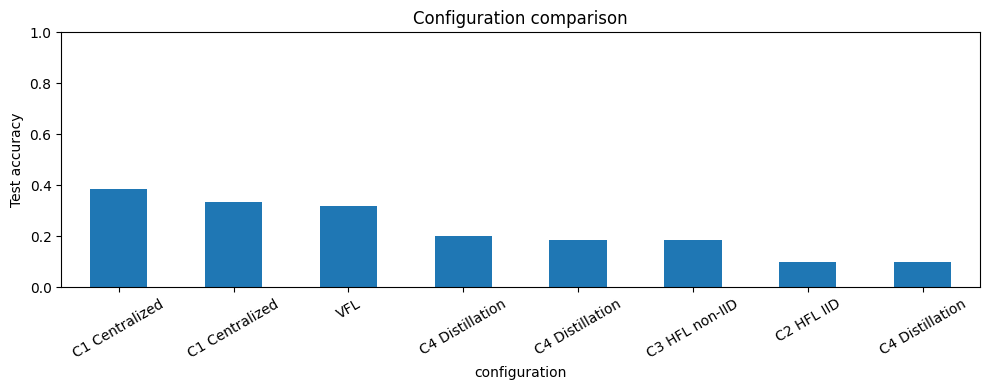

Best configuration: C1 Centralized | RS-CNN | accuracy= 0.3833
Saved comparison to outputs/comparison_metrics.csv


In [99]:
results_df = pd.DataFrame(experiment_rows).sort_values("test_accuracy", ascending=False).reset_index(drop=True)
results_df.to_csv("outputs/comparison_metrics.csv", index=False)
display(results_df)

try:
    import matplotlib.pyplot as plt

    ax = results_df.plot.bar(x="configuration", y="test_accuracy", legend=False, figsize=(10, 4), rot=30)
    ax.set_ylabel("Test accuracy")
    ax.set_ylim(0, 1)
    ax.set_title("Configuration comparison")
    plt.tight_layout()
    plt.savefig("reports/figures/configuration_comparison.png", dpi=160)
    plt.show()
except Exception as exc:
    print("Plot skipped:", exc)

best = results_df.iloc[0]
print("Best configuration:", best["configuration"], "|", best["model"], "| accuracy=", round(float(best["test_accuracy"]), 4))
print("Saved comparison to outputs/comparison_metrics.csv")

## 16. Assignment Summary

The notebook executes:

- metadata inspection and balanced subset selection;
- optional real `.ply` subset extraction from Cap3D ZIPs;
- C1 centralized baselines with PointGCN and RS-CNN interfaces;
- C2 horizontal federated learning with IID clients and manual FedAvg;
- C3 horizontal federated learning with non-IID clients and manual FedAvg;
- VFL with XYZ/RGB split ownership and embedding-only exchange;
- C4 knowledge distillation with CE + KL, `alpha`, and temperature `tau`;
- a comparison table saved to `outputs/comparison_metrics.csv`.

Default mode uses a synthetic proxy so the full workflow is always runnable. For final experimental results, set `PREPARE_REAL_SUBSET=True` once the ZIP is available, then set `USE_REAL_POINT_CLOUDS=True` and rerun.


In [100]:
!git status --short
!ls -lah outputs reports/figures checkpoints | sed -n '1,120p'

?? reports/figures/configuration_comparison.png
checkpoints:
total 96K
drwxr-xr-x  2 root root 4.0K May 31 17:45 .
drwxr-xr-x 12 root root 4.0K May 31 18:08 ..
-rw-r--r--  1 root root  41K May 31 18:32 pointgcn_centralized.pt
-rw-r--r--  1 root root  41K May 31 18:32 rscnn_centralized.pt

outputs:
total 44K
drwxr-xr-x  2 root root 4.0K May 31 17:45 .
drwxr-xr-x 12 root root 4.0K May 31 18:08 ..
-rw-r--r--  1 root root  966 May 31 18:32 comparison_metrics.csv
-rw-r--r--  1 root root  205 May 31 18:32 history_c2_hfl_iid.csv
-rw-r--r--  1 root root  203 May 31 18:32 history_c3_hfl_non-iid.csv
-rw-r--r--  1 root root  270 May 31 18:32 history_centralized_pointgcn.csv
-rw-r--r--  1 root root  272 May 31 18:32 history_centralized_rscnn.csv
-rw-r--r--  1 root root  317 May 31 18:32 history_kd_alpha_0.3_tau_2.0.csv
-rw-r--r--  1 root root  317 May 31 18:32 history_kd_alpha_0.5_tau_4.0.csv
-rw-r--r--  1 root root  317 May 31 18:32 history_kd_alpha_0.7_tau_4.0.csv
-rw-r--r--  1 root root  273 Ma